<img height='100' src='logotmg.png' width='900' alt='Talia Morchi' id='tmg_logo' title='Data Analyst Course'>
<center><h1><u>Welcome to the python for data analysis course </u></h1></center><center><h2>Class 7</h2></center>

<img height="100" src="time_to_practice.png" width="200" alt="Hands on" id="prc_time" title="Data Analyst Course">
<center><h1>practice 7.1</h1></center>

#### 1. Import the nessecary libraries

In [2]:
# 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show plots inside jupyter notebook
%matplotlib inline

#### 2. Import the titanic database from the lesson folder

In [6]:
# 2
titanic = pd.read_csv('titanic_train.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#### Dataset column explanation:
PassengerId: Id of every passenger

Pclass: There are 3 classes of passengers. Class1 (best one), Class2 and Class3

Survived: This feature have value 0 and 1. 0 = not survived, 1 for = survived.

Name: Name of passenger

Sex: Gender of passenger.

Age: Age of passenger.

SibSp: number of siblings or spouses abroad the titanic.

Parch: number of parents/children abroad the titanic

Ticket: Ticket no number.

Fare: passenger fare.

Cabin: The cabin number of passenger.

Embarked: port of embarkation C=Cherbourg, Q=Queenstown S=Southampton.

home.dest: The passanger destination

#### 3. Check how many NULL values in each column? 
Hint: use isnull() and .sum() methods

In [39]:
# 3
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### 4. Let's calculate and visualise distribution of our target variable - 'Survived'. 
####  How many survived and how many didn't survived from each gender?

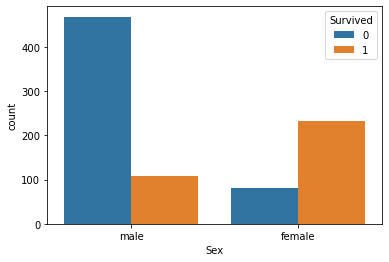

In [113]:
# 4
# Option 2:
mask = titanic['Survived'] == 1
sns.countplot(x='Sex', data=titanic, hue='Survived')

In [67]:
# Check the numbers
# Option 1
titanic.groupby(['Survived','Sex']).agg({'Sex':'count'})

# Option 2
titanic.pivot_table(values='PassengerId', columns='Survived', index='Sex', aggfunc='count')

Survived,0,1
Sex,,
female,81,233
male,468,109


#### 5.1 What is the age of passengers, split to 50 bins?

Text(0, 0.5, 'Frequency')

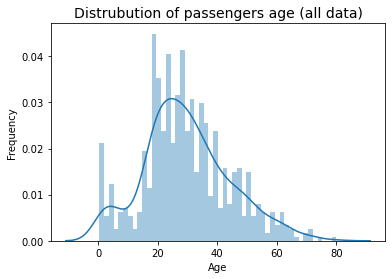

In [118]:
# 5.1
sns.distplot(titanic['Age'], bins=50)

plt.title('Distrubution of passengers age (all data)',fontsize= 14)
plt.xlabel('Age')
plt.ylabel('Frequency')

#### 5.2 Use a scatter plot to check the relationship between the passenger's age and his chances of survival. 
* Separate men and women.
* Who had a better chance to survive?

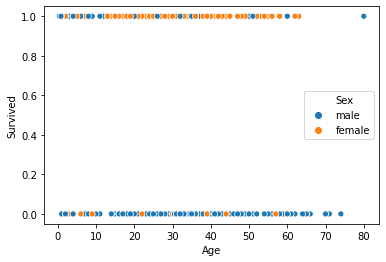

In [27]:
# 5.2
sns.scatterplot(data=titanic, x='Age', y='Survived', hue='Sex')

#### 5.3 Did age had a big influence on chances to survive?
#### To visualize use boxlot and stripplot showed together

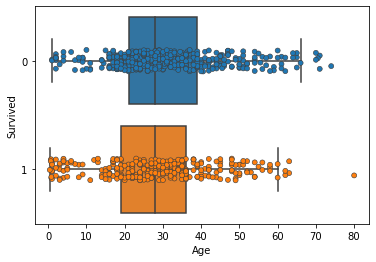

In [126]:
# 5.3
sns.boxplot(y = 'Survived', x = 'Age', data = titanic, fliersize = 0, orient = 'h')
sns.stripplot(y = 'Survived', x = 'Age', data = titanic, linewidth = 0.6, orient = 'h')

#### 6. Lets add th Sex, and use a violin graph to give a summary of the age range of men, women and children who survived and didnt survived

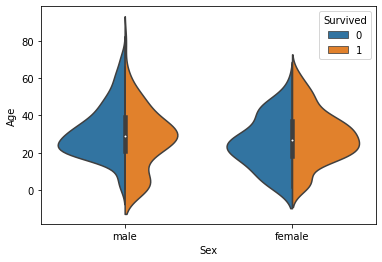

In [104]:
# 6

# The survival rate is:
#     * Good for children.
#     * High for women in the age range 20-50.
#     * Less for men as the age increases

sns.violinplot(x ="Sex", y ="Age", hue ="Survived", data = titanic, split = True)

#### 7. Use a heatmap to show the correlation between all the columns

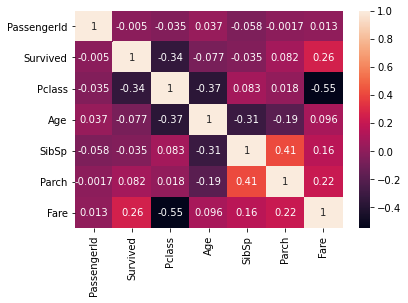

In [85]:
# 7
sns.heatmap (titanic.corr(), annot=True)

#### 8. Use a heatmap to show the correlation between Pclass and Survived

In [95]:
# 8

# Option 1
piv = titanic.pivot_table(values='PassengerId', columns='Survived', index='Pclass', aggfunc='count')
piv

# Option 2
# group = titanic.groupby(['Pclass', 'Survived']) 
# pclass_survived = group.size().unstack()

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


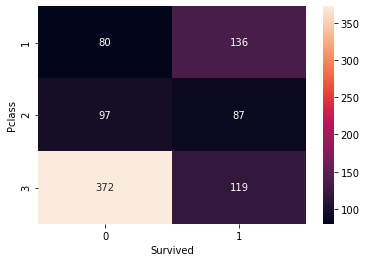

In [96]:
sns.heatmap(piv, annot = True, fmt ="d")

#### 9. Show the Fare distribution (can use kdeplot or distplot)

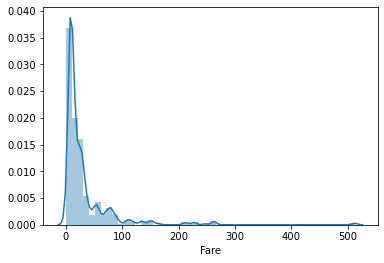

In [106]:
# Option 1:
# sns.kdeplot(titanic['Fare'])

# Option 2:
sns.distplot(titanic['Fare'])

<img height="100" src="time_to_practice.png" width="200" alt="Hands on" id="prc_time" title="Data Analyst Course">
<center><h1>practice 7.2</h1></center>

All the sections are properties for the plot

#### 1.1 Create a pairplot just for Fare, Age, Pclass and Sex columns
#### 1.2 Create serie according to gender
#### 1.3 Change the markers so each serie will have different marker

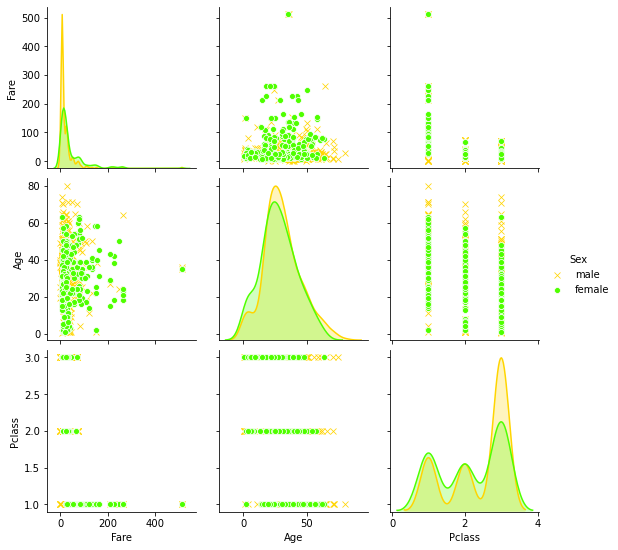

In [156]:
# 1
# sns.set_palette ('prism')
sns.pairplot(titanic[['Fare', 'Age', 'Pclass', 'Sex']], hue='Sex', markers=['x','o'])

#### 2.1 What is the distribution of the Fare per class?
#### 2.2 Change the plot size
#### 2.3 Chabge the plot palette
Hint: you can use swarmplot

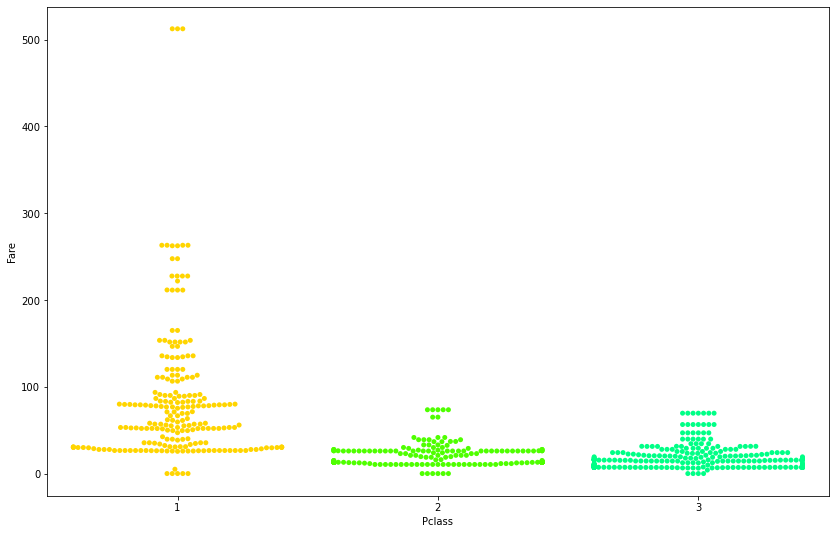

In [155]:
#2
plt.figure(figsize=(14,9))
sns.set_palette ('hsv')
sns.swarmplot(x='Pclass',y='Fare',data=titanic)

#### 3.1 Continued from the previous section change the properties of the plot, so you will have 2 series: Male, Female
#### 3.2 Change the size to be (14,9)
#### 3.3 Change the ticks of x axis to be brown, and inout direction
#### 3.4 Adjust the x label and y label: change the text, color, make it bold
#### 3.5 Add title to the plot

Text(0.5, 1.0, 'Fare per class')

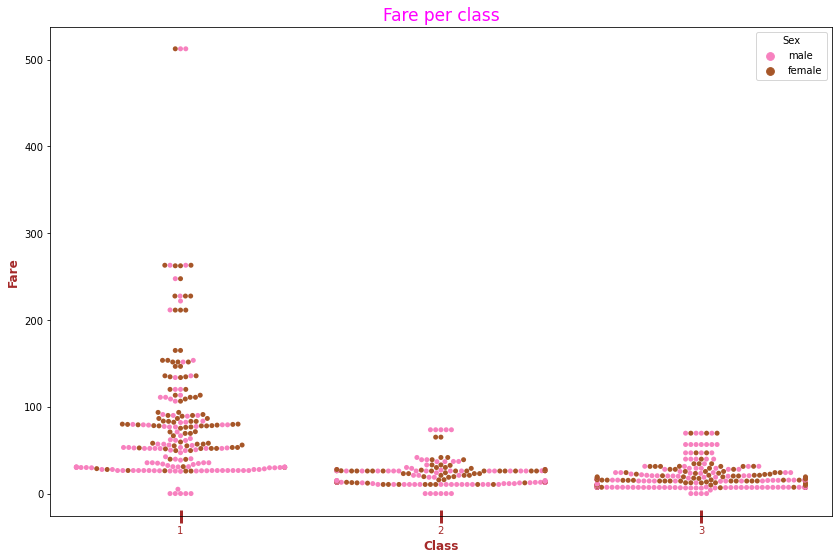

In [167]:
#3
plt.figure(figsize=(14,9))
sns.set_palette ('Set1_r')

sns.swarmplot(x='Pclass',y='Fare',data=titanic, hue='Sex')

plt.tick_params(axis='x', colors='brown', direction='inout', length=13, width=3)

plt.ylabel('Fare', fontweight='bold', color = 'brown', fontsize='12')
plt.xlabel('Class', fontweight='bold', color = 'brown', fontsize='12')

plt.title ('Fare per class', fontsize=17, color='magenta')
